## Prompt

> For Cc1cnc(N2CCN(C3=Nc4ccccc4Oc4ccc(Cl)cc43)CC2)s1, calculate logP. Them modify piperazine part in order to achieve lowest possible logP value, while retaining shape cosine similarity as close as possible to the query molecule. List 20 molecules and generate 4x5 grid. Use Enamine REAL database.

(Originally specified Freedom Space 5; switched to Enamine REAL once synthon inspection showed Freedom Space 5 fuses the tricycle and piperazine into one indivisible synthon, while Enamine REAL's synthon decomposition keeps them separate — see `note.md`. "Modify piperazine part" means the piperazine itself is free to change too, not just its substituent — only the tricycle stays fixed.)

In [1]:
from rdkit import Chem
from rdkit.Chem import Crippen

STARTING_SMILES = "Cc1cnc(N2CCN(C3=Nc4ccccc4Oc4ccc(Cl)cc43)CC2)s1"

starting_mol = Chem.MolFromSmiles(STARTING_SMILES)
starting_logp = Crippen.MolLogP(starting_mol)
print(f"Starting molecule logP (RDKit Crippen): {starting_logp:.3f}")

Starting molecule logP (RDKit Crippen): 5.111


### Step 2 - modify everything except the tricycle, via exact synthon matching

`enamine-real-v5a` doesn't support `dmc.substructure()`, but `dmc.search(..., include_synthons=True)` works there and returns each hit's exact per-building-block decomposition (`synthon_id` + SMILES with a `[U]` attachment point). The tricycle here is one standalone synthon (`[U]C1=Nc2ccccc2Oc2ccccc21`), separate from whatever's attached to it — filtering hits by an *exact* `synthon_id` match guarantees the literal same building block, more precise than an RDKit substructure check.

**First attempt was misleadingly narrow.** Searching only from the original (piperazine-containing) query and expanding from its own neighbors kept surfacing more piperazine-containing molecules - all from a single `reaction_id`. Checking a second, independent similarity metric (morgan alongside shape) still only found that same one reaction, which looked like confirmation that piperazine was unavoidable for this synthon. It wasn't: re-seeding the search with the tricycle capped by something *other* than piperazine (e.g. a plain methylamino group) immediately surfaced a **second reaction** (`rt_c7e98c69c...`) using the exact same tricycle synthon, producing genuinely piperazine-free analogues (direct aryl, ether, methylene, and amide linkages). The first approach's blind spot: similarity search can only find what's similar enough to already-found anchors to rank in the top-K, and every anchor so far had been piperazine-shaped.

So the final approach seeds the search from **several differently-capped versions of the tricycle** (not just the original query), across two similarity metrics, then expands further from whatever non-piperazine hits turn up. This surfaced 1,315 unique exact-synthon matches across both reactions (1,090 piperazine-based, 225 not), instead of 278 from a single reaction. Every result below records exactly which reference molecule and method its similarity score came from - scores are only directly comparable to "the query" for hits found from the original query itself; others are real scores relative to a different (but exact-synthon, hence tricycle-identical) anchor.

In [2]:
import deepmedchem as dmc

DATABASE = "enamine-real-v5a"
LIMIT = 200
TOP_N = 20
NON_PIPERAZINE_EXPANSION_ANCHORS = 6

# Seed queries: the original molecule, plus the tricycle capped a few different ways so the
# search isn't anchored only to piperazine-shaped neighbors.
SEED_QUERIES = [
    STARTING_SMILES,
    "CNC1=Nc2ccccc2Oc2ccccc21",
    "NC1=Nc2ccccc2Oc2ccccc21",
    "CCNC1=Nc2ccccc2Oc2ccccc21",
]

base_result = dmc.search(
    STARTING_SMILES, database=DATABASE, method="shape", limit=LIMIT, include_synthons=True
)
top_synthons = base_result.results[0]["synthons"]
for s in top_synthons:
    print(f"slot {s['slot']}: {s['synthon_id']}  {s['smiles']}")
tricycle_synthon_id = top_synthons[1]["synthon_id"]  # the tricycle, confirmed by inspection above


def search_for_synthon(query_smiles, method, scored_against):
    result = dmc.search(
        query_smiles, database=DATABASE, method=method, limit=LIMIT, include_synthons=True
    )
    return {
        hit["product_id"]: {**hit, "scored_against": scored_against, "scored_method": method}
        for hit in result.results
        if any(s["synthon_id"] == tricycle_synthon_id for s in (hit.get("synthons") or []))
    }


pool = {}
for seed in SEED_QUERIES:
    for method in ("morgan", "shape"):
        new = search_for_synthon(seed, method, scored_against=seed)
        pool.update({pid: h for pid, h in new.items() if pid not in pool})

original_reaction_id = base_result.results[0]["reaction_id"]
non_piperazine_hits = [h for h in pool.values() if h["reaction_id"] != original_reaction_id]
print(f"\nafter seed queries: {len(pool)} exact-synthon matches "
      f"({len(non_piperazine_hits)} from a second reaction)")

for anchor in non_piperazine_hits[:NON_PIPERAZINE_EXPANSION_ANCHORS]:
    for method in ("morgan", "shape"):
        new = search_for_synthon(anchor["smiles"], method, scored_against=anchor["smiles"])
        pool.update({pid: h for pid, h in new.items() if pid not in pool})

reaction_counts = {}
for h in pool.values():
    reaction_counts[h["reaction_id"]] = reaction_counts.get(h["reaction_id"], 0) + 1
print(f"final pool: {len(pool)} exact-synthon matches, by reaction: {reaction_counts}")

scored = []
for hit in pool.values():
    mol = Chem.MolFromSmiles(hit["smiles"])
    logp = Crippen.MolLogP(mol)
    scored.append((logp, hit, mol))

scored.sort(key=lambda row: row[0])
lowest = scored[:TOP_N]

print(f"\nLowest {TOP_N} logP among exact-synthon matches (starting logP was {starting_logp:.3f}):")
for logp, hit, _ in lowest:
    print(
        f"logP={logp:.3f}  {hit['scored_method']}={hit['score']:.3f} vs {hit['scored_against'][:30]!r}"
        f"  rxn={hit['reaction_id'][:12]}  {hit['smiles']}"
    )

slot 0: st_915ac4c58918a62569f46c97  Cc1cnc(N2CC[N]([U])CC2)s1
slot 1: st_8455fdde7a24714f4d13b3c2  [U][C]1=Nc2ccccc2Oc2ccccc21



after seed queries: 613 exact-synthon matches (170 from a second reaction)


final pool: 1315 exact-synthon matches, by reaction: {'rt_98c055f0a122f008fc1bbc75': 1090, 'rt_c7e98c69c8e92615ba2c90d6': 225}



Lowest 20 logP among exact-synthon matches (starting logP was 5.111):
logP=1.954  morgan=0.565 vs 'C[C@H]1C[C@H](NC2=Nc3ccccc3Oc3'  rxn=rt_c7e98c69c  O[C@@H]1C[C@@H](O)C1NC1=Nc2ccccc2Oc2ccccc21
logP=1.954  morgan=0.565 vs 'C[C@H]1C[C@H](NC2=Nc3ccccc3Oc3'  rxn=rt_c7e98c69c  O[C@@H]1C[C@H](O)[C@H]1NC1=Nc2ccccc2Oc2ccccc21
logP=2.383  shape=0.852 vs 'C[C@@H](O)c1ccc(NC2=Nc3ccccc3O'  rxn=rt_c7e98c69c  CN(C)CC(O)CNC1=Nc2ccccc2Oc2ccccc21
logP=2.455  shape=0.747 vs 'CNC1=Nc2ccccc2Oc2ccccc21'  rxn=rt_c7e98c69c  Cc1nnn(CCNC2=Nc3ccccc3Oc3ccccc32)n1
logP=2.537  morgan=0.565 vs 'CCNC1=Nc2ccccc2Oc2ccccc21'  rxn=rt_c7e98c69c  c1ccc2c(c1)N=C(NCCCn1cnnn1)c1ccccc1O2
logP=2.582  shape=0.846 vs 'C[C@@H](O)c1ccc(NC2=Nc3ccccc3O'  rxn=rt_c7e98c69c  C[C@@H](CNC1=Nc2ccccc2Oc2ccccc21)C(N)=O
logP=2.665  shape=0.733 vs 'NC1=Nc2ccccc2Oc2ccccc21'  rxn=rt_c7e98c69c  O=C1NC2(CO1)CN(C1=Nc3ccccc3Oc3ccccc31)C2
logP=2.703  morgan=0.582 vs 'CNc1cnc(CNC2=Nc3ccccc3Oc3ccccc'  rxn=rt_98c055f0a  NS(=O)(=O)c1ccc(CNC2=Nc3ccccc3

### Step 3 — 4x5 grid of the lowest-logP exact-synthon matches

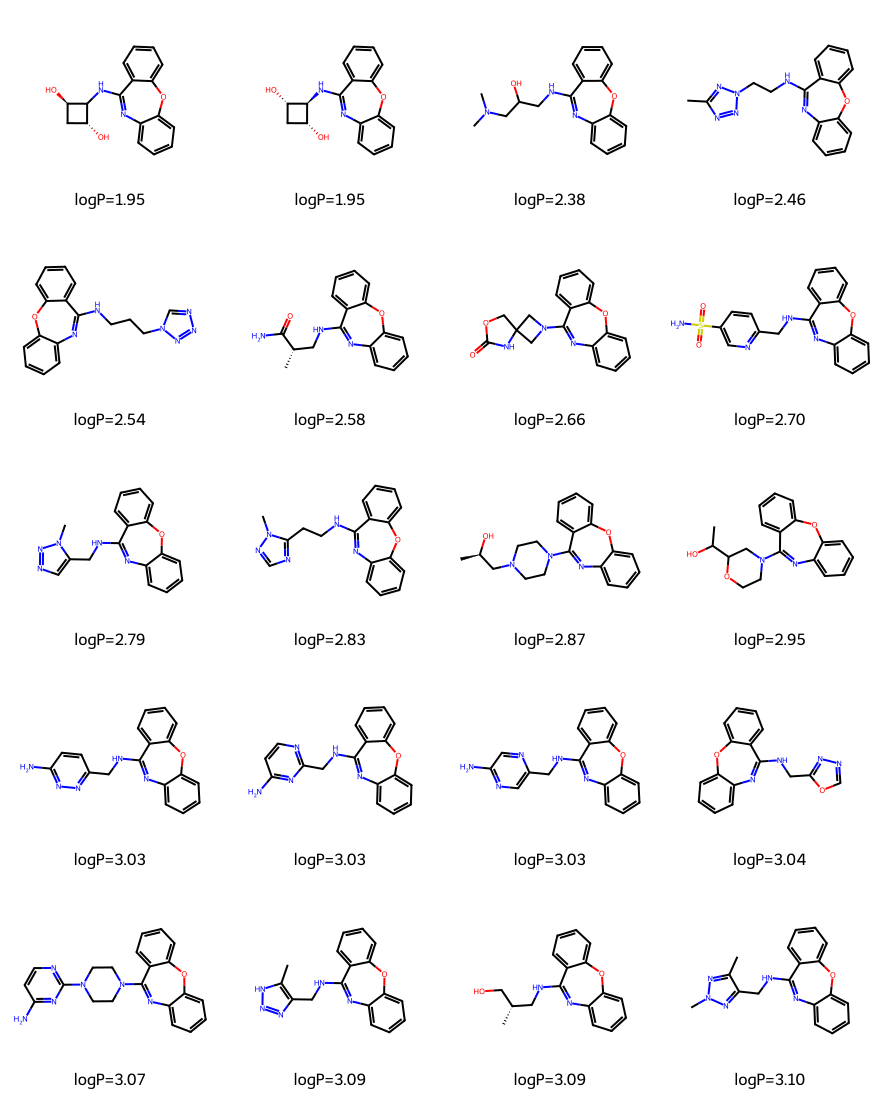

In [3]:
from rdkit.Chem import Draw

mols = [mol for _, _, mol in lowest]
legends = [f"logP={logp:.2f}" for logp, _, _ in lowest]

Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)